# 22 · MILP, átomos laminares y atlas de razones

## Qué responde esta versión

Este cuaderno registra los experimentos del plan semanal y corrige dos
ambigüedades del prototipo original:

1. $V^{\mathcal L}$ es ahora el **óptimo exacto sobre todas las bibliotecas
   laminares fijas** para $n\le6$, no el mejor de tres árboles heurísticos.
2. Las marginales exactas de un átomo no se vuelven a multiplicar. Para
   predecir $R_t$ se conserva la distribución Bernoulli condicionada al
   conteo del átomo.

Las etiquetas tienen un significado estricto:

- **TEOREMA:** demostrado aparte y usado bajo sus hipótesis.
- **VERIFICADO:** identidad comprobada contra otro cálculo exacto.
- **EVIDENCIA:** resultado de una malla o búsqueda finita; no es una cota.
- **REFUTADO:** afirmación empírica que los datos de esta versión contradicen.

Los barridos largos escriben CSV por instancia. Este notebook los lee, audita
invariantes y conserva tablas, figuras y conclusiones junto al código que las
produce.

In [1]:
import json, sys
from pathlib import Path

ROOT = next((path for path in (Path.cwd(), *Path.cwd().parents)
             if (path / 'augmented').is_dir()), None)
if ROOT is None:
    raise RuntimeError('No se encontró la raíz con augmented/')
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from augmented.bayesian import _poisson_binomial_pmf, exact_pool_pmf
from augmented.core import indices_from_mask, mask_from_indices
from augmented.independence_gap import tv_distance
from augmented.laminar_benchmarks import (
    four_quantities, maximal_laminar_libraries,
)
from augmented.laminar_inference import (
    laminar_forest_marginals, laminar_pool_pmf,
)
from augmented.scenario_milp import (
    brute_best_pool_scenarios, exact_prior_scenarios,
    milp_best_pool_scenarios,
)

DATA = ROOT / 'augmented' / 'data' / 'laminar_week'
FIGURES = ROOT / 'augmented' / 'notebooks' / 'figures' / '22_laminar_week'
required = [
    'atlas_instances.csv', 'atlas_cells.csv', 'adversarial_minima.csv',
    'homogeneous_b2.csv', 'independence_gap.csv',
    'milp_particle_sweep.csv', 'pipeline_n40_summary.csv',
    'pipeline_n40_trace.csv',
]
missing = [name for name in required if not (DATA / name).exists()]
assert not missing, f'Faltan artefactos: {missing}'

plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.25,
})
print(f'raíz: {ROOT}')
print(f'artefactos auditados: {len(required)}/{len(required)}')

raíz: /Users/hectorbecerrilvillamil/Desktop/GroupCounting/group-count-dynamic
artefactos auditados: 8/8


## 1. Las cuatro cantidades: definiciones que sí coinciden con el plan

Para cada $(p,u,B,G)$ del atlas medimos:

1. $V^*$: óptimo dinámico aumentado sin restricción;
2. $V^{\mathcal L}=\max_{\mathcal L}V(\mathcal L)$: mejor política dinámica
   dentro de una biblioteca laminar fija;
3. $V^{greedy}_{\mathcal L}$: valor exacto del greedy miope dentro de una
   jerarquía balanceada determinista, construida ordenando $(1-p_i)u_i$;
4. $V^{static}_{bin}$: mejor diseño binario no adaptativo con traslapes.

La cuarta cantidad tiene el mismo welfare con resultados binarios o conteos,
porque las acciones se fijan antes de observar resultados y sólo un cero
acredita utilidad.

### Por qué $V^{\mathcal L}$ es exacto para $n\le6$

Los pools factibles son vértices de un grafo; dos vértices son adyacentes si
los pools son disjuntos o uno contiene al otro. Una biblioteca laminar es un
clique. Basta recorrer cliques maximales, porque toda familia laminar se puede
extender a una maximal y añadir acciones no reduce el valor óptimo. En el caso
más grande del atlas, $(n,G)=(6,3)$, sólo hay 105 bibliotecas maximales.

In [2]:
library_counts = pd.DataFrame([
    {'n': n, 'G': G, 'pools': sum(len(list(__import__('itertools').combinations(range(n), g)))
                                  for g in range(1, G + 1)),
     'bibliotecas maximales': len(maximal_laminar_libraries(n, G))}
    for n in (4, 5, 6) for G in (2, 3)
])
display(library_counts)

# Auditoría directa de una instancia chica.
audit = four_quantities(
    [0.18, 0.37, 0.51, 0.24, 0.66],
    [1.0, 2.2, 0.7, 3.1, 1.4],
    B=3, G=3,
)
display(pd.Series({key: value for key, value in audit.items()
                   if key.startswith('V_') or key.startswith('ratio_')},
                  name='valor'))
assert audit['V_greedy_laminar'] <= audit['V_rollout_laminar'] + 1e-10
assert audit['V_greedy_laminar'] <= audit['V_laminar'] + 1e-10
assert audit['V_laminar'] <= audit['V_star'] + 1e-10
assert audit['V_static_binary'] <= audit['V_star'] + 1e-10
print('VERIFICADO: orden de benchmarks y policy improvement en la auditoría.')

,n,G,pools,bibliotecas maximales
0,4,2,10,3
1,4,3,14,15
2,5,2,15,15
3,5,3,25,30
4,6,2,21,15
5,6,3,41,105


V_star                  4.893296
V_laminar               4.747445
V_greedy_laminar        4.671257
V_rollout_laminar       4.681824
V_static_binary         4.562000
ratio_laminar_opt       0.970194
ratio_greedy_laminar    0.983952
ratio_static_opt        0.932296
ratio_greedy_static     1.023949
ratio_rollout_greedy    1.002262
Name: valor, dtype: float64

VERIFICADO: orden de benchmarks y policy improvement en la auditoría.


## 2. Átomos: marginal exacta no significa independencia

### Nota de vocabulario

En la sesión del 27 de julio convivieron dos nociones de "átomo" y conviene
fijar cuál usa este cuaderno. Una es *hoja del árbol*: un pool de la familia
que no tiene hijos. La otra —la del Lema A y la que se usa aquí— es
*residuo*: lo que queda de un pool al quitarle sus hijos inmediatos.

Las dos coinciden exactamente en las hojas, y sólo ahí. En un nodo interior
con hijos que no lo cubren por completo, el residuo es no vacío y **no** es
ninguna hoja: es un bloque propio, con su propio conteo, que ninguna prueba
observó directamente. Por eso hay un átomo por pool y no uno por hoja, y por
eso la partición cubre a toda la población testeada. Cuando este cuaderno
dice "átomo" siempre quiere decir residuo.

Para un nodo observado $A$ con hijos inmediatos $C$,

$$
D_A=A\setminus\bigcup_C C,
\qquad
c(D_A)=c(A)-\sum_Cc(C).
$$

Los $D_A$ son disjuntos y el posterior factoriza **entre átomos**. Dentro de
un átomo con conteo intermedio, las variables siguen siendo dependientes. La
marginal individual

$$
P(Z_i=1\mid \sum_{j\in D}Z_j=c)
=\frac{p_iP(\sum_{j\in D\setminus\{i\}}Z_j=c-1)}
       {P(\sum_{j\in D}Z_j=c)}
$$

es exacta, pero el producto de esas marginales no reconstruye la ley conjunta.
`laminar_pool_pmf` conserva cada Bernoulli condicionada y convoluciona las
contribuciones de los átomos independientes.

In [3]:
p_demo = np.array([0.12, 0.31, 0.46, 0.68, 0.23, 0.57, 0.39, 0.76])
root = mask_from_indices([0, 1, 2, 3])
child = mask_from_indices([0, 1])
other = mask_from_indices([4, 5])
history = ((root, 2), (child, 1), (other, 1))
hierarchy = {root: (child,), child: (), other: ()}
marginals, atoms = laminar_forest_marginals(p_demo, history, hierarchy)

candidate = mask_from_indices([2, 3])  # compatible y dentro de un átomo
pmf_enum = np.asarray(exact_pool_pmf(p_demo, history, candidate, len(p_demo)))
pmf_atoms = laminar_pool_pmf(p_demo, atoms, candidate)
pmf_product = np.asarray(_poisson_binomial_pmf(
    [marginals[i] for i in indices_from_mask(candidate, len(p_demo))]
))

comparison = pd.DataFrame({
    'r': np.arange(len(pmf_enum)),
    'enumeración exacta': pmf_enum,
    'átomos condicionados': pmf_atoms,
    'producto de marginales': pmf_product,
})
display(comparison)
print('TV(átomos, exacta)  =', tv_distance(pmf_atoms, pmf_enum))
print('TV(producto, exacta)=', tv_distance(pmf_product, pmf_enum))
np.testing.assert_allclose(pmf_atoms, pmf_enum, atol=2e-12, rtol=2e-12)
assert tv_distance(pmf_product, pmf_enum) > 0.05

,r,enumeración exacta,átomos condicionados,producto de marginales
0,0,0.0,0.0,0.204272
1,1,1.0,1.0,0.591456
2,2,0.0,0.0,0.204272


TV(átomos, exacta)  = 0.0
TV(producto, exacta)= 0.40854373816359457


**TEOREMA (Lema A).** La resta de conteos transforma el historial
laminar en restricciones sobre bloques disjuntos y el prior producto
condicionado factoriza entre esos bloques. Esto justifica inferencia exacta
por mensajes Poisson-binomial.

**Consecuencia operacional.** Para un rollout exacto no basta pasar el vector
de marginales: hay que pasar los átomos con sus conteos (o una representación
equivalente de su distribución condicionada).

## 3. Proposición B: qué garantiza y qué no

Sea $g$ el greedy dentro de una biblioteca fija $\mathcal L$. El rollout
evalúa cada acción $a\in\mathcal L$ con recompensa inmediata más la
continuación de $g$. La acción que elegiría $g$ está entre las candidatas, así
que el máximo del rollout no puede ser menor. Aplicando el mismo argumento a
cada estado sucesor, una inducción hacia atrás en el presupuesto da

$$V^{rollout}_{\mathcal L}(s,b)\ge V^g_{\mathcal L}(s,b).$$

La hipótesis sustantiva es que las esperanzas usadas en cada $Q$ sean exactas.
El Lema A las proporciona mientras se conserva la distribución de los átomos
y las acciones mantienen el historial laminar. La proposición **no** afirma
que rollout domine al MILP plano, al estático o a $V^*$.

La demostración completa quedó extraída en
`augmented/paper/proposicion_b_policy_improvement.md`.

In [4]:
atlas = pd.read_csv(DATA / 'atlas_instances.csv')
tol = 2e-9
assert (atlas.ratio_rollout_greedy >= 1 - tol).all()
print(f"mínimo rollout/greedy en {len(atlas):,} filas: "
      f"{atlas.ratio_rollout_greedy.min():.12f}")
print(f"mejora estricta: {(atlas.ratio_rollout_greedy > 1 + tol).mean():.1%}")

mínimo rollout/greedy en 2,592 filas: 1.000000000000
mejora estricta: 35.5%


## 4. Atlas v1: 2,592 filas exactas

Malla completa:

- prevalencia media $\bar p\in\{0.05,0.10,\ldots,0.90\}$;
- tasas homogéneas o Beta bimodal calibrada a la misma media;
- utilidades planas o log-uniformes normalizadas;
- $n\in\{4,5,6\}$, $B\in\{2,3\}$, $G\in\{2,3\}$;
- tres réplicas por celda.

Las cuatro razones declaradas son

$$
\frac{V^{\mathcal L}}{V^*},\quad
\frac{V^{greedy}_{\mathcal L}}{V^{\mathcal L}},\quad
\frac{V^{static}_{bin}}{V^*},\quad
\frac{V^{greedy}_{\mathcal L}}{V^{static}_{bin}}.
$$

El CSV conserva $p$, $u$, semillas, valores, razones, tiempos y bibliotecas
por instancia; `atlas_cells.csv` conserva mínimo, máximo, media, mediana e IDs
de los extremos de cada celda.

In [5]:
ratio_columns = [
    'ratio_laminar_opt', 'ratio_greedy_laminar',
    'ratio_static_opt', 'ratio_greedy_static',
]
labels = {
    'ratio_laminar_opt': 'V_L / V*',
    'ratio_greedy_laminar': 'greedy_L / V_L',
    'ratio_static_opt': 'static_bin / V*',
    'ratio_greedy_static': 'greedy_L / static_bin',
}
extremes = []
for column in ratio_columns:
    worst = atlas.loc[atlas[column].idxmin()]
    best = atlas.loc[atlas[column].idxmax()]
    extremes.append({
        'razón': labels[column],
        'mínimo': worst[column],
        'instancia mínima': int(worst.instance),
        'régimen mínimo': f"p={worst.base_p:.2f}, n/B/G={worst.n}/{worst.B}/{worst.G}, "
                          f"{worst.rate_mode}, {worst.utility_mode}",
        'máximo': best[column],
    })
display(pd.DataFrame(extremes))
print(f"V_L = V* en {(atlas.ratio_laminar_opt >= 1-tol).mean():.1%} de la malla")
print(f"greedy_L >= estático en {(atlas.ratio_greedy_static >= 1-tol).mean():.1%}")
print(f"rollout_L >= estático en "
      f"{(atlas.V_rollout_laminar >= atlas.V_static_binary-tol).mean():.1%}")

,razón,mínimo,instancia mínima,régimen mínimo,máximo
0,V_L / V*,0.928023,2000,"p=0.70, n/B/G=6/3/2, beta_bimodal, flat",1.00000
1,greedy_L / V_L,0.747313,1027,"p=0.40, n/B/G=4/2/3, beta_bimodal, flat",1.00000
2,static_bin / V*,0.804290,2472,"p=0.90, n/B/G=4/3/2, homogeneous, flat",1.00000
3,greedy_L / static_bin,0.748722,1027,"p=0.40, n/B/G=4/2/3, beta_bimodal, flat",1.09141


V_L = V* en 52.5% de la malla
greedy_L >= estático en 67.0%
rollout_L >= estático en 74.7%


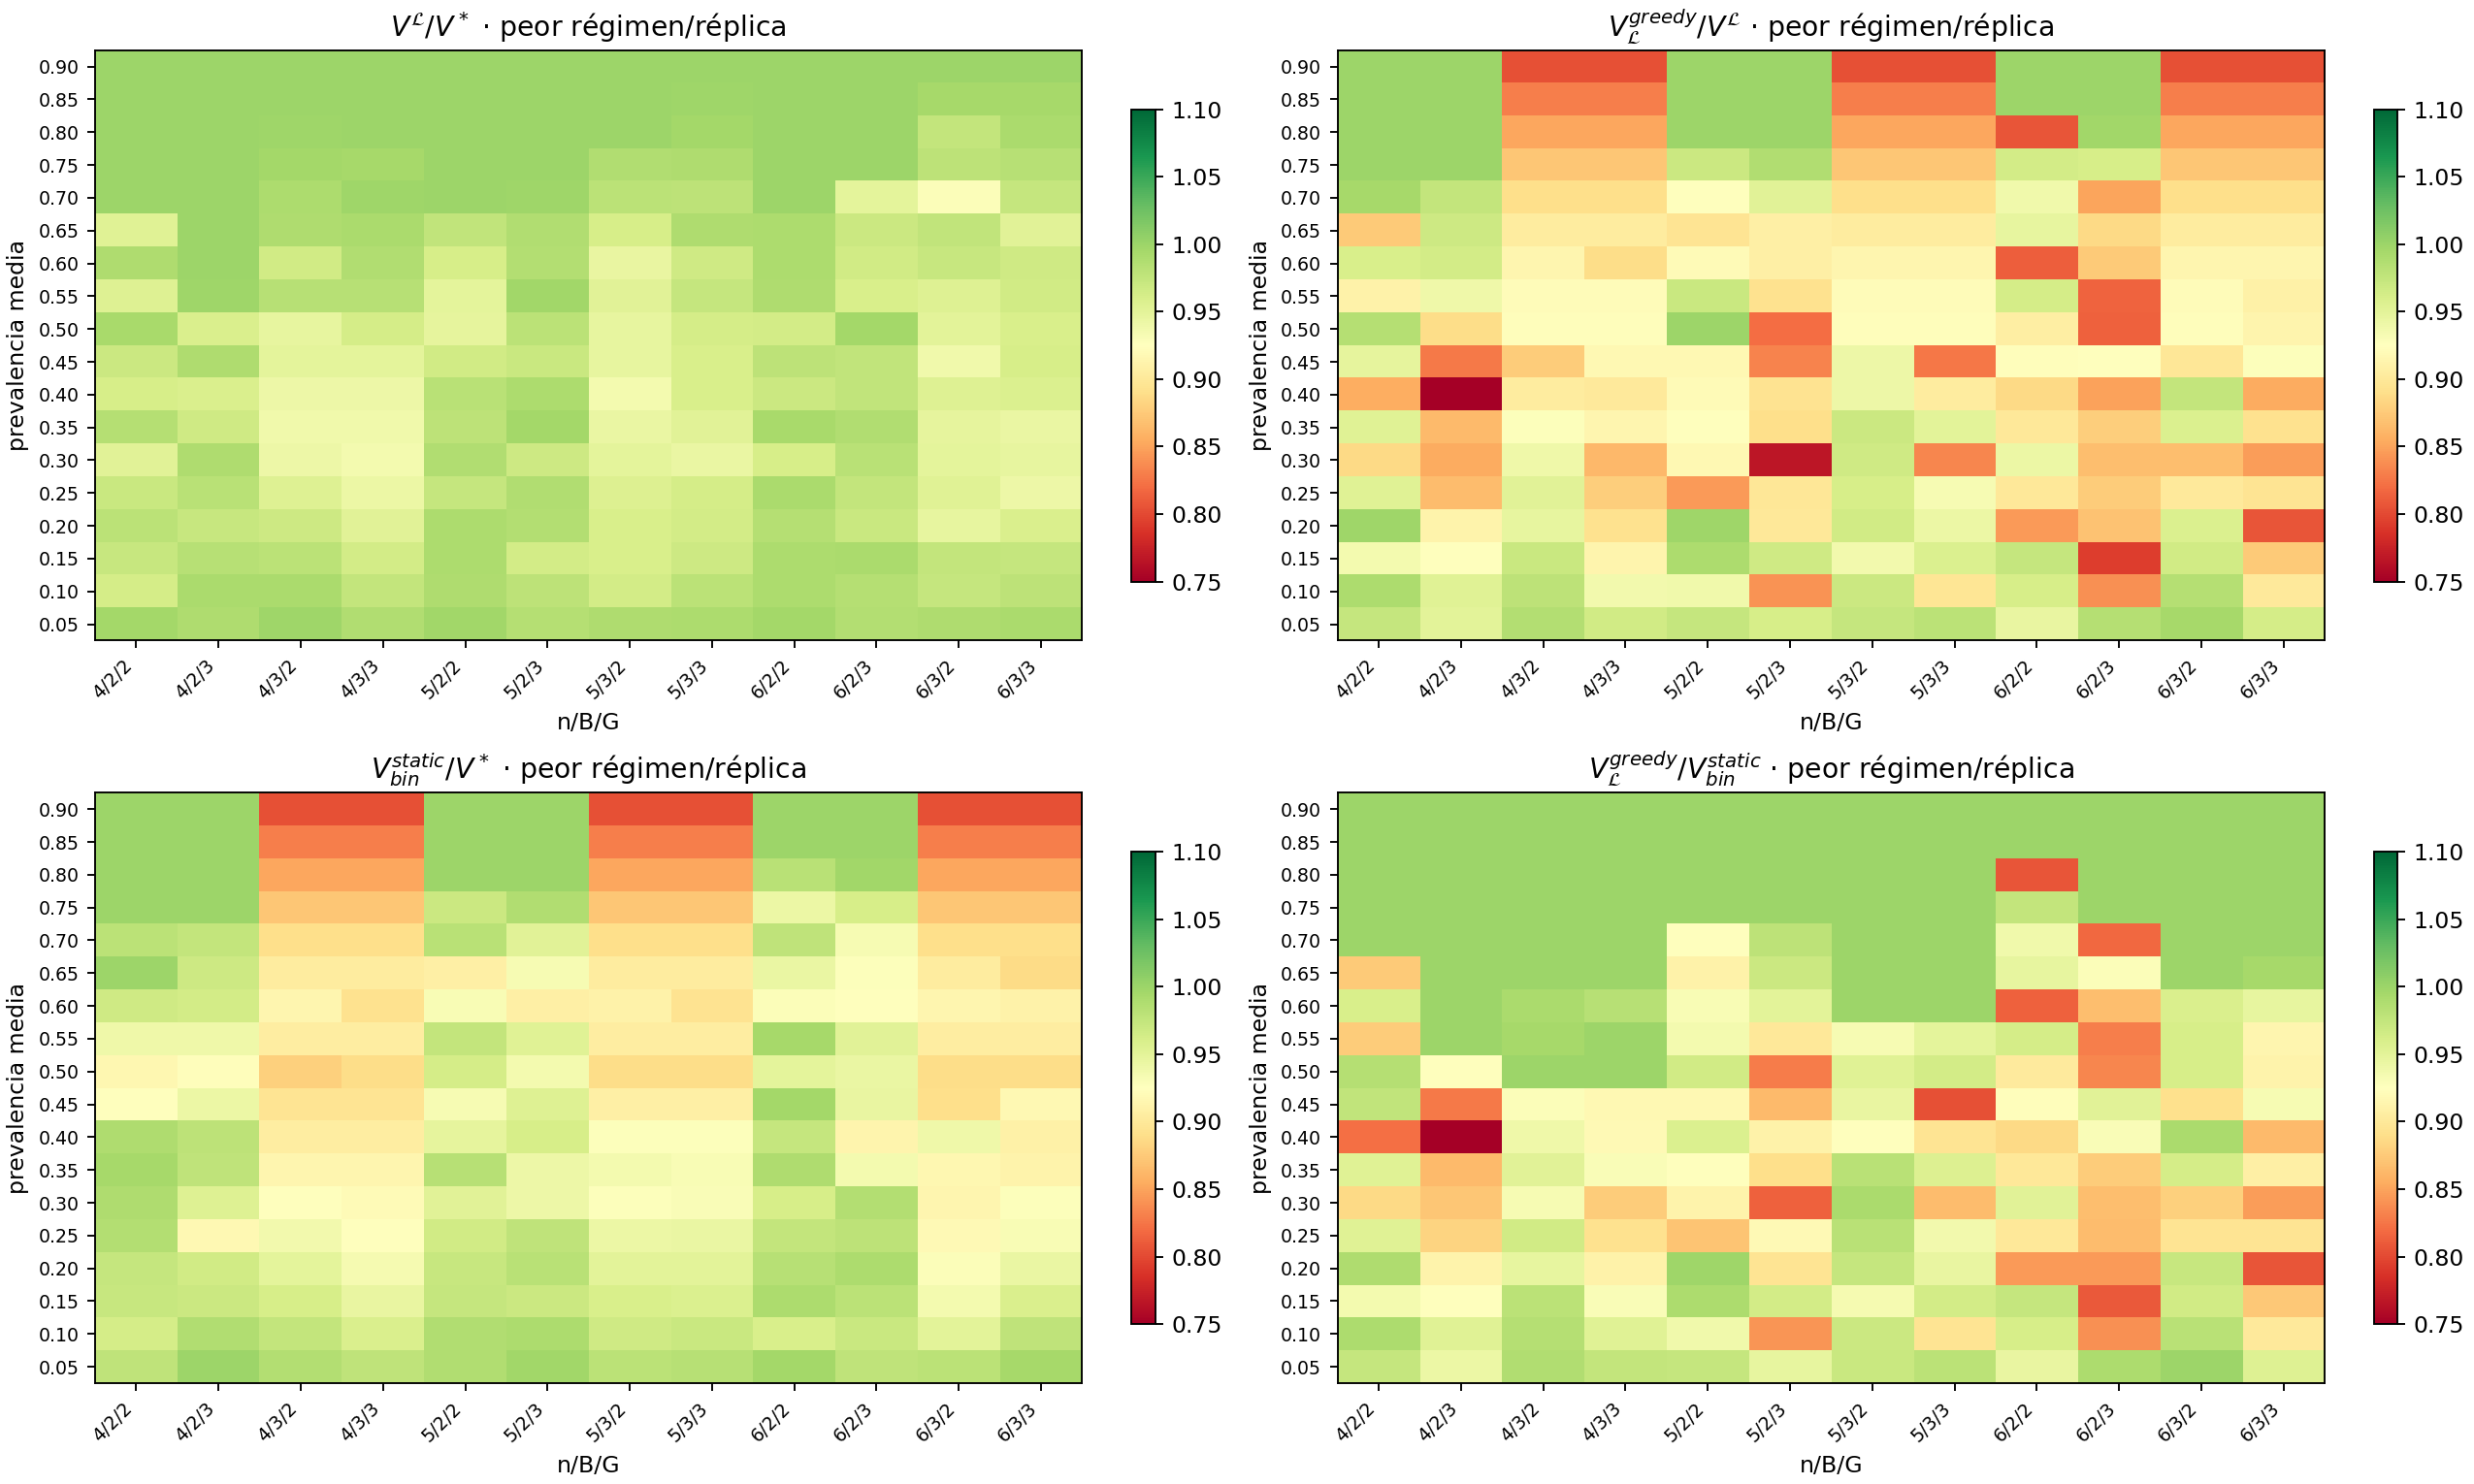

In [6]:
display(Image(filename=str(FIGURES / 'atlas_ratio_heatmaps.png')))

In [7]:
mode_summary = atlas.groupby(['rate_mode', 'utility_mode']).agg(
    laminar_min=('ratio_laminar_opt', 'min'),
    laminar_mean=('ratio_laminar_opt', 'mean'),
    greedy_static_min=('ratio_greedy_static', 'min'),
    greedy_static_mean=('ratio_greedy_static', 'mean'),
).reset_index()
display(mode_summary)

worst_laminar = atlas.loc[atlas.ratio_laminar_opt.idxmin()]
print('peor V_L/V*')
print(worst_laminar[[
    'instance','base_p','n','B','G','rate_mode','utility_mode',
    'V_star','V_laminar','V_greedy_laminar','V_rollout_laminar',
    'V_static_binary','ratio_laminar_opt'
]])
print('p =', np.round(json.loads(worst_laminar.p), 5).tolist())
print('u =', np.round(json.loads(worst_laminar.u), 5).tolist())

,rate_mode,utility_mode,laminar_min,laminar_mean,greedy_static_min,greedy_static_mean
0,beta_bimodal,flat,0.928023,0.993454,0.748722,0.988024
1,beta_bimodal,log_uniform,0.932390,0.993528,0.803445,0.982239
2,homogeneous,flat,0.935030,0.991155,0.875807,0.989429
3,homogeneous,log_uniform,0.943191,0.992629,0.863896,0.994073


peor V_L/V*
instance                     2000
base_p                        0.7
n                               6
B                               3
G                               2
rate_mode            beta_bimodal
utility_mode                 flat
V_star                   1.585236
V_laminar                1.471135
V_greedy_laminar           1.4138
V_rollout_laminar        1.471135
V_static_binary            1.4138
ratio_laminar_opt        0.928023
Name: 2000, dtype: object
p = [0.78715, 0.05649, 0.91113, 0.78611, 0.91552, 0.7436]
u = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


### Lectura del atlas

- **EVIDENCIA:** el peor cociente laminar exacto es **0.9280**, debajo del
  0.943 preliminar del prototipo.
- **REFUTADO sin hipótesis de régimen:** “greedy laminar domina al estático
  binario en casi todo el espacio”. Ocurre en 67.0% de esta malla; rollout lo
  eleva a 74.7%, todavía lejos de una dominancia casi universal.
- El problema no es sólo la restricción laminar. El peor
  $V^{greedy}_{\mathcal L}/V^{\mathcal L}$ es 0.7473: construir/optimizar la
  jerarquía y planear dentro de ella son pérdidas distintas.
- La Proposición B sí sobrevive: rollout nunca cae debajo de su propio greedy.

## 5. Búsqueda adversaria desde las peores regiones

Se partió del peor punto del atlas en prevalencia baja, media y alta. En cada
trayectoria se perturba una coordenada de $p$ o de $\log u$, se renormaliza la
utilidad y sólo se acepta una mejora del objetivo
$V^{\mathcal L}/V^*$. Son 24 propuestas por región: búsqueda local
reproducible, no certificación global.

,region,seed_instance,n,B,G,iteration,incumbent_ratio,p,u
0,low,555,6,3,2,15,0.943885,"[0.26463381369138794, 0.25046278282038487, 0.2...","[0.3045895320760726, 0.634761975338223, 0.5411..."
1,middle,756,4,3,3,0,0.935030,"[0.3, 0.3, 0.3, 0.3]","[1.0, 1.0, 1.0, 1.0]"
2,high,2000,6,3,2,22,0.906890,"[0.787148890096605, 0.01, 0.8540192893513814, ...","[1.0074066236459516, 1.0074066236459516, 1.401..."


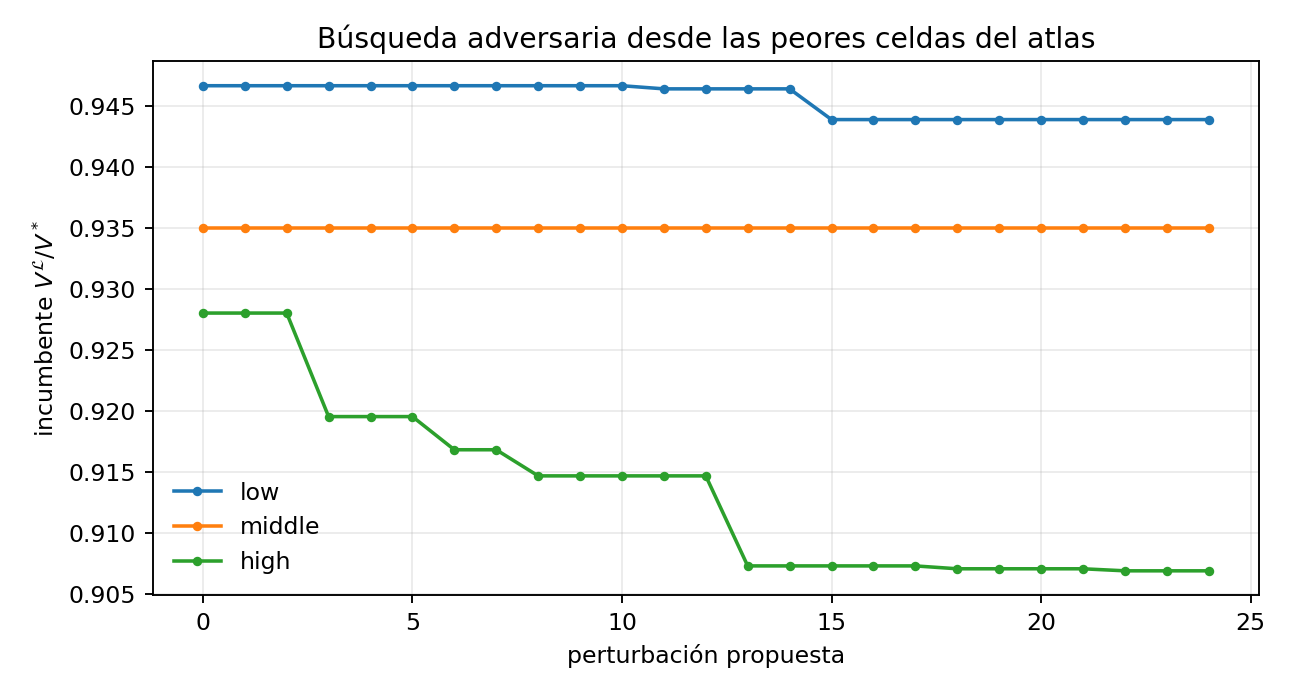

mínimo adversario: 0.9068898546420788


In [8]:
adversarial = pd.read_csv(DATA / 'adversarial_minima.csv')
display(adversarial[[
    'region','seed_instance','n','B','G','iteration','incumbent_ratio','p','u'
]])
display(Image(filename=str(FIGURES / 'adversarial_trajectories.png')))
print('mínimo adversario:', adversarial.incumbent_ratio.min())

**EVIDENCIA:** la perturbación local bajó la región alta de 0.9280 a
**0.9069**, pero no encontró una instancia por debajo de 0.9. Esto no prueba
una cota 0.9: sólo fija una semilla más exigente para búsqueda futura.

## 6. Régimen especial $B\le2$, $p_i=p$, $u_i=1$

$B=1$ es una identidad: la acción óptima pertenece a alguna biblioteca
laminar maximal, por lo que $V^{\mathcal L}=V^*$. Para $B=2$ se barrió
$p=0.05,0.075,\ldots,0.9$, $n\in\{4,5,6\}$ y $G\in\{2,3\}$.

El objetivo del experimento era encontrar una razón menor que 0.9 o aislar un
caso prometedor para una cota. El resultado fue más fuerte como evidencia:
todos los puntos dieron igualdad numérica.

,count,min,max
B,,,
1,210,1.0,1.0
2,210,1.0,1.0


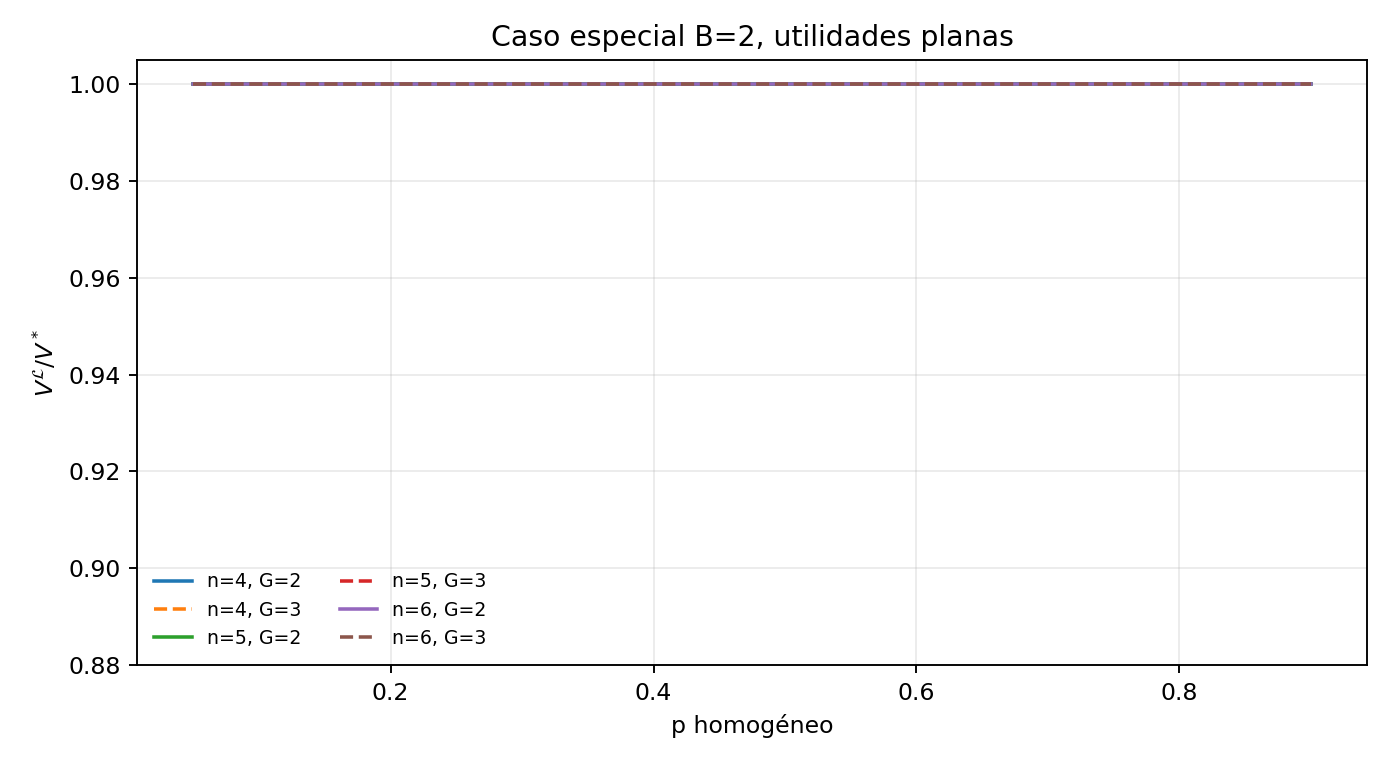

In [9]:
homogeneous = pd.read_csv(DATA / 'homogeneous_b2.csv')
summary_h = homogeneous.groupby('B').ratio_laminar_opt.agg(['count','min','max'])
display(summary_h)
assert np.max(np.abs(homogeneous.ratio_laminar_opt - 1.0)) < 1e-9
display(Image(filename=str(FIGURES / 'homogeneous_b2.png')))

**TEOREMA para $B=1$; EVIDENCIA para $B=2$.** La malla sugiere la
conjetura $V^{\mathcal L}=V^*$ bajo priors y utilidades homogéneos con
$B\le2$. La igualdad de una malla finita no autoriza todavía a escribirla como
teorema para $B=2$. El atlas muestra además que la frontera importa: con
$B=3$, $n=4$, $G=3$, $p=0.3$ y $u=1$ ya aparece razón 0.9350.

## 7. Diagnóstico del gap de independencia

En 80 priors/historias ramificadas se comparó la distribución exacta de
$R_t$ con:

- Poisson-binomial construida multiplicando marginales posteriores;
- distribución calculada desde los átomos condicionados.

Se incluyeron pools disjuntos, nodos ya observados, descendientes compatibles
y pools con cruce no laminar.

,category,product_tv_mean,product_tv_max,atom_tv_mean,atom_tv_max
0,crossing_nonlaminar,1.455361e-01,4.992418e-01,2.784231e-17,2.220446e-16
1,disjoint,5.783134e-17,2.220446e-16,5.297412e-17,2.220446e-16
2,nested_compatible,1.411128e-01,4.993237e-01,0.000000e+00,0.000000e+00
3,observed_node,2.750072e-01,5.998617e-01,0.000000e+00,0.000000e+00


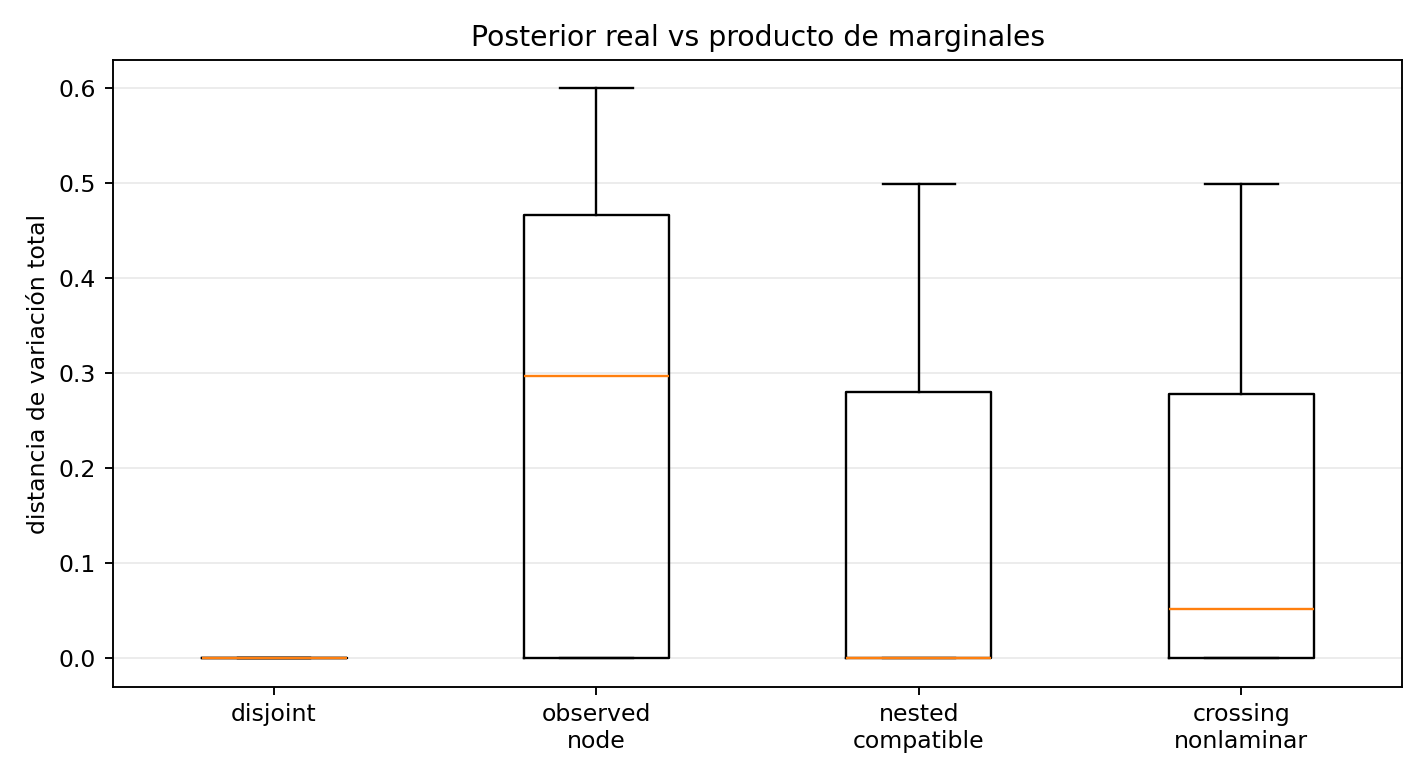

,r,exacta,producto,átomos
0,0,0.0,0.051595,0.0
1,1,0.0,0.248336,0.0
2,2,1.0,0.400138,1.0
3,3,0.0,0.248336,0.0
4,4,0.0,0.051595,0.0


In [10]:
gap = pd.read_csv(DATA / 'independence_gap.csv')
gap_summary = gap.groupby('category').agg(
    product_tv_mean=('tv_product','mean'),
    product_tv_max=('tv_product','max'),
    atom_tv_mean=('tv_atom','mean'),
    atom_tv_max=('tv_atom','max'),
).reset_index()
display(gap_summary)
assert gap.tv_atom.max() < 2e-10
display(Image(filename=str(FIGURES / 'independence_gap.png')))

worst_gap = gap.loc[gap.tv_product.idxmax()]
display(pd.DataFrame({
    'r': range(len(json.loads(worst_gap.exact_pmf))),
    'exacta': json.loads(worst_gap.exact_pmf),
    'producto': json.loads(worst_gap.product_pmf),
    'átomos': json.loads(worst_gap.atom_pmf),
}))

**REFUTADO:** “si el pool es compatible con la familia laminar, el
producto de marginales es exacto”. Un descendiente compatible tuvo TV media
0.141 y máxima 0.499; un nodo observado llegó a 0.600. Lo que el Lema A hace
exacto es el cálculo que conserva las distribuciones de los átomos, no el
producto posterior.

Un pool no laminar también puede evaluarse exactamente para **la próxima**
acción desde los átomos actuales. El problema aparece después de observarlo:
el nuevo historial deja de ser laminar y se pierde el cierre estructural.

## 8. MILP: objetivo real, gap de optimización y error de partículas

El selector usa escenarios $z^s$ con pesos $\pi_s$, variables binarias de
selección $x_i$, indicadores de limpieza $y_s$ y una variable de welfare
$v_s$ por escenario. Una envolvente big-$M$ exacta impone

$$v_s=y_s\sum_i u_i x_i.$$

La formulación tiene $n+2S$ variables. En el barrido, el pool del MILP se
comparó con enumerar todos los pools sobre la **misma muestra**; después se
evaluó bajo el prior verdadero y se comparó con el pool verdaderamente óptimo.

Esto separa tres números que suelen confundirse:

1. **objetivo**, por ejemplo 0.99: welfare esperado y por tanto un real;
2. **MIP gap**: tolerancia/optimalidad del solver;
3. **regret estadístico**: diferencia entre optimizar $S$ partículas y la
   distribución verdadera.

,S,value_ratio_mean,value_ratio_min,pool_match,true_regret_mean,empirical_identity_error,mip_gap
0,25,0.932716,0.735366,0.5625,0.159326,0.0,0.0
1,50,0.988688,0.958789,0.6875,0.020127,0.0,0.0
2,100,0.983921,0.857174,0.6875,0.039851,0.0,0.0
3,250,0.995405,0.958789,0.8125,0.009328,0.0,0.0
4,500,0.996221,0.958789,0.8750,0.006332,0.0,0.0


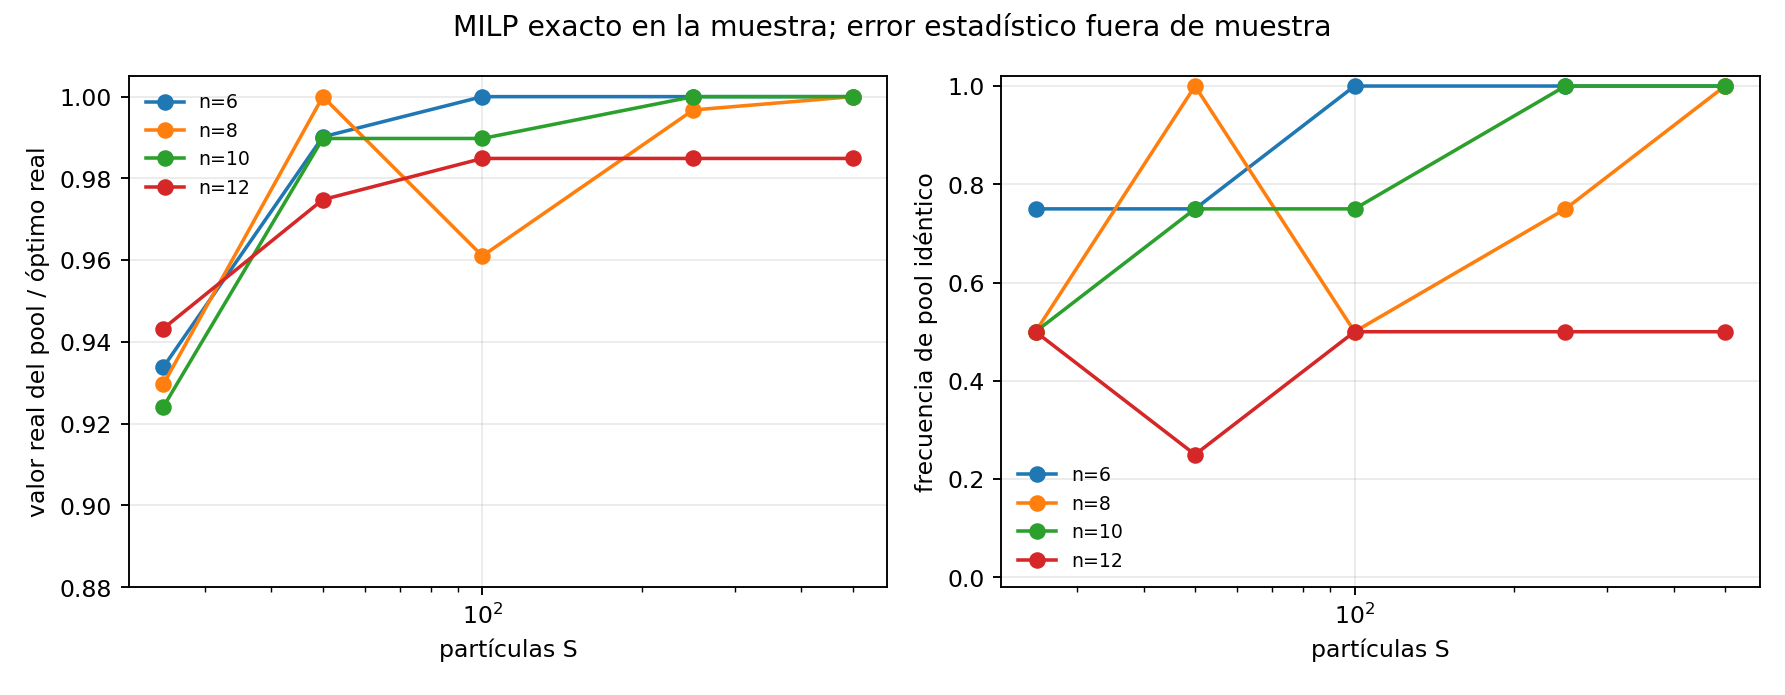

rango de objetivos reales del MILP: (0.6585621832516687, 4.1158990433318)


In [11]:
milp_sweep = pd.read_csv(DATA / 'milp_particle_sweep.csv')
milp_summary = milp_sweep.groupby('S').agg(
    value_ratio_mean=('value_ratio','mean'),
    value_ratio_min=('value_ratio','min'),
    pool_match=('pool_match','mean'),
    true_regret_mean=('true_regret','mean'),
    empirical_identity_error=('empirical_identity_error','max'),
    mip_gap=('mip_gap','max'),
).reset_index()
display(milp_summary)
assert milp_sweep.empirical_identity_error.max() < 1e-8
assert milp_sweep.mip_gap.max() < 1e-8
display(Image(filename=str(FIGURES / 'milp_particle_sweep.png')))
print('rango de objetivos reales del MILP:',
      (milp_sweep.empirical_objective.min(), milp_sweep.empirical_objective.max()))

**VERIFICADO:** las 80 corridas tuvieron identidad exacta entre MILP
y fuerza bruta en su muestra, con `mip_gap=0`. **EVIDENCIA estadística:** con
$S=25$ la razón media fuera de muestra fue 0.933; con $S=500$, 0.996. La curva
no tiene por qué ser monótona en cada realización finita, aun usando muestras
anidadas.

## 9. Pipeline $n=40,S=100$

La corrida completa usa $B=3,G=3$:

$$
\text{partículas}\to\text{MILP raíz}\to R=r
\to\text{átomo exacto}\to\text{rollout en una jerarquía fija}.
$$

Se evaluaron 250 perfiles fuera de muestra. Los controles son greedy plano
con producto de marginales y MILP miope reoptimizado sin rollout. También se
incluye el greedy de la misma jerarquía para aplicar correctamente la
Proposición B.

,method,profiles,mean_utility,standard_error,exact_expected_utility,zero_rate,root_members
0,flat_independence,250,11.267128,0.405157,NaN,0.124,"[2, 17, 18]"
1,myopic_milp,250,11.460189,0.424679,NaN,0.136,"[2, 17, 18]"
2,laminar_greedy,250,10.068747,0.387709,10.289508,0.108,"[2, 17, 18]"
3,laminar_rollout,250,10.068747,0.387709,10.289508,0.108,"[2, 17, 18]"


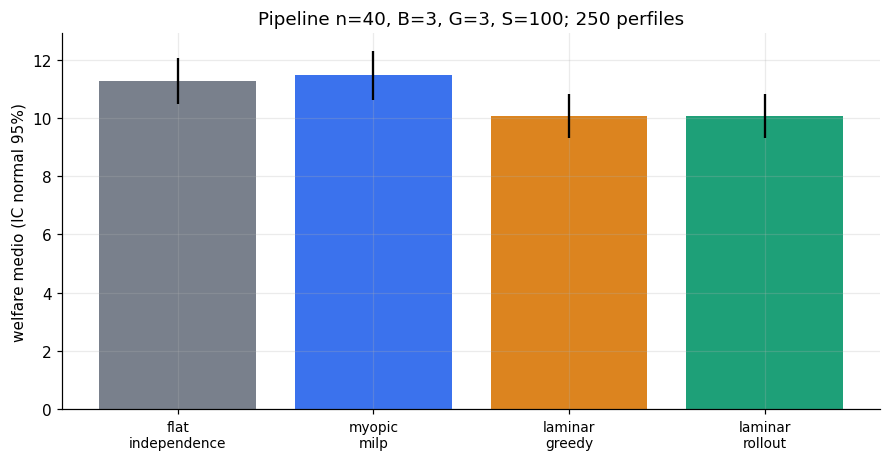

,step,pool_members,observed_count,tv_product,tv_atom_vs_block
0,2,"[12, 15, 22]",0,2.775558e-17,4.163336e-17
1,3,"[1, 14, 37]",0,1.734723e-18,1.734723e-18


In [12]:
pipeline = pd.read_csv(DATA / 'pipeline_n40_summary.csv')
display(pipeline[[
    'method','profiles','mean_utility','standard_error',
    'exact_expected_utility','zero_rate','root_members',
]])

fig, ax = plt.subplots(figsize=(8.2, 4.3))
x = np.arange(len(pipeline))
ax.bar(x, pipeline.mean_utility, yerr=1.96*pipeline.standard_error,
       color=['#6b7280','#2563eb','#d97706','#059669'], alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(pipeline.method.str.replace('_','\n'), fontsize=9)
ax.set_ylabel('welfare medio (IC normal 95%)')
ax.set_title('Pipeline n=40, B=3, G=3, S=100; 250 perfiles')
plt.tight_layout(); plt.show()

trace = pd.read_csv(DATA / 'pipeline_n40_trace.csv')
display(trace[['step','pool_members','observed_count','tv_product','tv_atom_vs_block']])
assert trace.tv_atom_vs_block.max() < 2e-10

**EVIDENCIA de esta instancia, no ranking universal.** El MILP miope
obtuvo 11.46, el greedy plano 11.27 y el pipeline laminar 10.07. La
restricción a una jerarquía fija costó más que el rollout recuperó. Dentro de
esa misma jerarquía, greedy y rollout empataron exactamente en esperanza
(10.2895), consistente con la Proposición B. El resultado evita una lectura
incorrecta: policy improvement protege contra el baseline propio, no contra
políticas con otra clase de acciones.

## 10. Tablas de subconjuntos y actualización incremental

La sesión del 27 de julio pidió un objeto por prueba: dada $T$ con conteo
observado $R$, la probabilidad $P(R(T')=r'\mid R(T)=R)$ para **todo**
$T'\subseteq T$ y todo $r'$. Y preguntó si, cuando una prueba posterior parte
$T$ en dos átomos, las tablas de los hijos se pueden derivar de la del padre
en vez de recalcularse.

Ambas respuestas salen de una identidad. Como el prior es producto, para
$S\subseteq T$

$$P(R(S)=r\mid R(T)=R)=\frac{PB_S(r)\,PB_{T\setminus S}(R-r)}{PB_T(R)},$$

donde $PB_S$ es la pmf Poisson-binomial del bloque $S$. Condicionar no toca
los bloques: reponderа una familia de pmf que **no depende de ninguna
observación**. El objeto reusable es esa familia —la *caché de subconjuntos*—
y no la tabla condicional.

Para la división el argumento es exacto, no aproximado. Probar
$T'\subseteq T$ y observar $r'$ crea los átomos $T'$ (conteo $r'$) y
$D=T\setminus T'$ (conteo $R-r'$). Todo bloque que aparece en la tabla de un
hijo es un subconjunto de $T$, así que ya está en la caché: los hijos cuestan
**cero convoluciones nuevas**.

### La tabla, explícita

El objeto pedido en la sesión, con números, para un pool de cuatro personas
con $p=(0.2,0.4,0.6,0.8)$ y conteo observado $R(t)=2$. Las columnas son los
$2^{|t|}$ subconjuntos, las filas los conteos posibles $r'$, y **cada columna
suma uno**: es la distribución del conteo de ese subconjunto. La última
columna, $t'=t$, concentra toda la masa en $r'=2$, que es lo ya observado.

Dos celdas merecen atención. La columna $\{0,1,2\}$ vale exactamente cero en
$r'=0$: con dos positivos entre cuatro personas es imposible que tres estén
limpias, porque los dos positivos no caben en la única restante. La tabla
respeta esa coherencia por construcción; un producto de marginales le daría
masa positiva. Y la fila $r'=0$, ponderada por utilidades, **es** la decisión
greedy $\max_{t'\subseteq t}u(t')\,P((t',0)\mid(t,r))$.

In [13]:
from augmented.laminar_tables import (
    absolute_mask, conditional_subset_table, split_subset_tables,
    subset_pmf_cache,
)

demo_p = np.array([0.2, 0.4, 0.6, 0.8])
demo_u = np.array([1.0, 1.5, 0.8, 2.0])
demo_pool, demo_count = 0b1111, 2

demo_cache = subset_pmf_cache(demo_p, demo_pool)
demo_table = conditional_subset_table(demo_cache, demo_count)


def _name(mask):
    members = indices_from_mask(mask, 4)
    return '{' + ','.join(str(member) for member in members) + '}'


columns, frame = {}, {}
for index in range(1 << 4):
    mask = absolute_mask(demo_cache, index)
    size = mask.bit_count()
    column = np.full(5, np.nan)
    column[: size + 1] = demo_table[index, : size + 1]
    columns[_name(mask)] = mask
    frame[_name(mask)] = column

shown = pd.DataFrame(frame, index=[f'r={r}' for r in range(5)])
display(shown.round(4))
assert np.allclose(np.nansum(shown.values, axis=0), 1.0)
assert shown.loc['r=0', '{0,1,2}'] == 0.0
assert shown.loc['r=2', '{0,1,2,3}'] == 1.0

greedy = pd.DataFrame([
    {'t_prima': name,
     'u(t_prima)': float(demo_u[indices_from_mask(mask, 4)].sum()),
     'P(r=0 | obs)': float(demo_table[
         [key for key in range(1 << 4)
          if absolute_mask(demo_cache, key) == mask][0], 0]),
     }
    for name, mask in columns.items() if mask
])
greedy['producto'] = greedy['u(t_prima)'] * greedy['P(r=0 | obs)']
display(greedy.sort_values('producto', ascending=False).head(6)
        .reset_index(drop=True).round(4))
print('el greedy elige el argmax de la última columna, no el de utilidad')

,{},{0},{1},"{0,1}",{2},"{0,2}","{1,2}","{0,1,2}",{3},"{0,3}","{1,3}","{0,1,3}","{2,3}","{0,2,3}","{1,2,3}","{0,1,2,3}"
r=0,1.0,0.8625,0.658,0.5353,0.342,0.2379,0.0892,0.0000,0.1375,0.0892,0.0335,0.000,0.0149,0.000,0.0000,0.0
r=1,NaN,0.1375,0.342,0.4498,0.658,0.7286,0.8216,0.8625,0.8625,0.8216,0.7286,0.658,0.4498,0.342,0.1375,0.0
r=2,NaN,NaN,NaN,0.0149,NaN,0.0335,0.0892,0.1375,NaN,0.0892,0.2379,0.342,0.5353,0.658,0.8625,1.0
r=3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,0.000,NaN,0.000,0.0000,0.0
r=4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


,t_prima,u(t_prima),P(r=0 | obs),producto
0,"{0,1}",2.5,0.5353,1.3383
1,{1},1.5,0.6580,0.9870
2,{0},1.0,0.8625,0.8625
3,"{0,2}",1.8,0.2379,0.4283
4,{3},2.0,0.1375,0.2751
5,{2},0.8,0.3420,0.2736


el greedy elige el argmax de la última columna, no el de utilidad


La caché es el otro objeto, y es el que conviene guardar. Contiene la
pmf de cada bloque **sin condicionar**, que no depende de ninguna
observación; la tabla de arriba se arma con dos entradas suyas y una
división.

In [14]:
for mask in (0b0011, 0b1100, 0b1111):
    index = [key for key in range(1 << 4)
             if absolute_mask(demo_cache, key) == mask][0]
    print(f'PB_{_name(mask):<10} = {np.round(demo_cache.pmfs[index], 4)}')

inside, outside = 0b0011, 0b1100
manual = (demo_cache.pmfs[inside][1] * demo_cache.pmfs[outside][1]
          / demo_cache.pmfs[0b1111][2])
print(f'\nP(R({_name(inside)})=1 | R(t)=2) por la identidad: {manual:.6f}')
print(f'                                    en la tabla: '
      f'{demo_table[inside, 1]:.6f}')
assert abs(manual - demo_table[inside, 1]) < 1e-12

# La misma caché sirve para cualquier conteo observado, sin recalcular nada.
otras = pd.DataFrame({
    f'R(t)={other}': conditional_subset_table(demo_cache, other)[
        [0b0011, 0b1100, 0b0001], 0]
    for other in (1, 2, 3)
}, index=['{0,1}', '{2,3}', '{0}'])
display(otras.round(4))
print('filas r=0 para tres observaciones distintas, misma caché')

PB_{0,1}      = [0.48 0.44 0.08]
PB_{2,3}      = [0.08 0.44 0.48]
PB_{0,1,2,3}  = [0.0384 0.2464 0.4304 0.2464 0.0384]

P(R({0,1})=1 | R(t)=2) por la identidad: 0.449814
                                    en la tabla: 0.449814


,R(t)=1,R(t)=2,R(t)=3
"{0,1}",0.8571,0.5353,0.0000
"{2,3}",0.1429,0.0149,0.0000
{0},0.9610,0.8625,0.6234


filas r=0 para tres observaciones distintas, misma caché


,candidates,cache_convolutions,sweep_scratch_convolutions,one_speedup,sweep_speedup,max_abs_error,ahorro_convoluciones
G,,,,,,,
4,13.3333,15.0,94.6667,1.1824,1.2353,0.0,6.3111
6,56.0000,63.0,1012.0000,1.2395,1.2356,0.0,16.0635
8,241.3333,255.0,10768.0000,1.1832,1.2239,0.0,42.2275
10,964.5000,1023.0,97869.0000,1.2189,1.2171,0.0,95.6686
12,512.0000,4095.0,174203.0000,1.1993,1.1962,0.0,42.5404


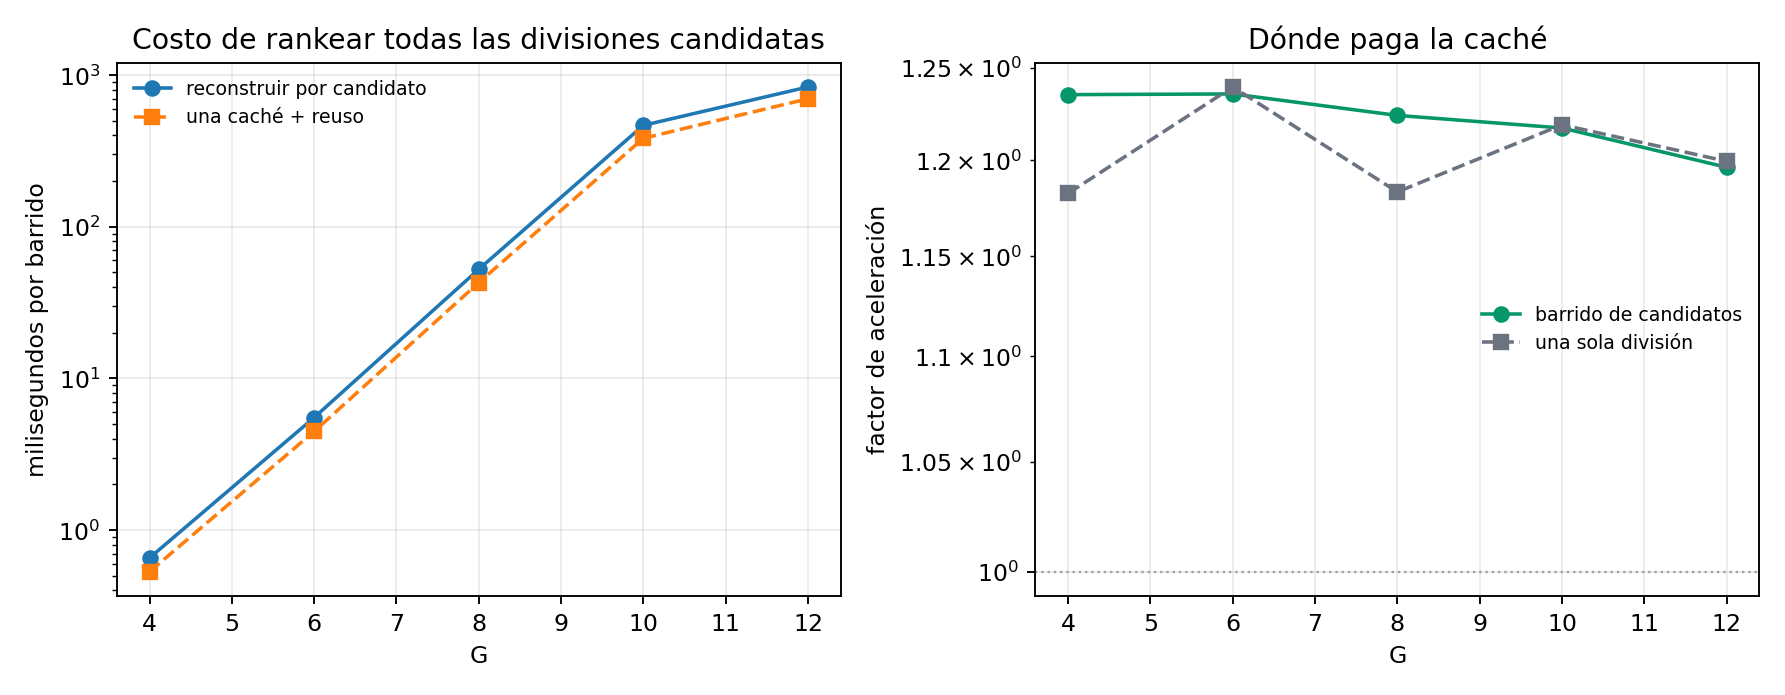

In [15]:
tables = pd.read_csv(DATA / 'subset_tables.csv')
summary = tables.groupby('G')[[
    'candidates','cache_convolutions','sweep_scratch_convolutions',
    'one_speedup','sweep_speedup','max_abs_error',
]].mean()
summary['ahorro_convoluciones'] = (
    summary.sweep_scratch_convolutions / summary.cache_convolutions
)
display(summary.round(4))

assert tables.max_abs_error.max() == 0.0
assert (tables.sweep_reuse_convolutions == 0).all()
display(Image(filename=str(FIGURES / 'subset_tables.png')))

**VERIFICADO:** las tablas reusadas son idénticas a las construidas
desde cero —error máximo exactamente $0.0$, no "cercano a cero"— y la
división gasta cero convoluciones. Con $G=10$, rankear las ~965 divisiones
candidatas cuesta 97,869 convoluciones desde cero contra 1,023 con la caché:
un factor de **96×** en trabajo estructural.

**EVIDENCIA que corrige la expectativa:** ese factor **no** se traduce en
tiempo de pared. La aceleración medida es apenas ~1.2× en todas las $G$
probadas, porque materializar la tabla completa ($2^G$ filas) domina el costo
y ese trabajo es idéntico con caché o sin ella. La conclusión operativa
invierte el diseño que pidió la sesión: la caché es lo que hay que guardar y
la tabla es lo que **no** conviene materializar; las filas deben consultarse
por demanda. La pregunta de la sesión tiene respuesta afirmativa en teoría, y
el cuello de botella real está en otro lado.

## 11. Dónde sí paga la jerarquía laminar

La sesión predijo que el ejemplo insignia no puede exhibir ganancia laminar:
con utilidades planas y sin pruebas previas, el primer paso del greedy
laminar coincide con el estático, y anticipó que el laminar "nada más es útil
cuando las tasas de infección son muy altas". El atlas permite verificar esa
intuición en vez de asumirla.

,region,instances,share_greedy_beats_static,share_rollout_beats_static,best_gain_rollout_static,best_p,best_n,best_B,best_G,best_utility_mode
0,global,2592,0.6698,0.7465,1.2433,0.90,4,3,2,flat
1,utilidades planas,1296,0.7022,0.7762,1.2433,0.90,4,3,2,flat
2,utilidades dispersas,1296,0.6373,0.7168,1.1651,0.90,6,3,2,log_uniform
3,tasas homogéneas,1296,0.7647,0.8750,1.2433,0.90,4,3,2,flat
4,tasas dispersas,1296,0.5748,0.6181,1.0914,0.50,4,2,2,flat
5,prevalencia alta,1008,0.9603,0.9821,1.2433,0.90,4,3,2,flat
6,prevalencia baja,576,0.4045,0.5087,1.0420,0.15,6,3,2,log_uniform


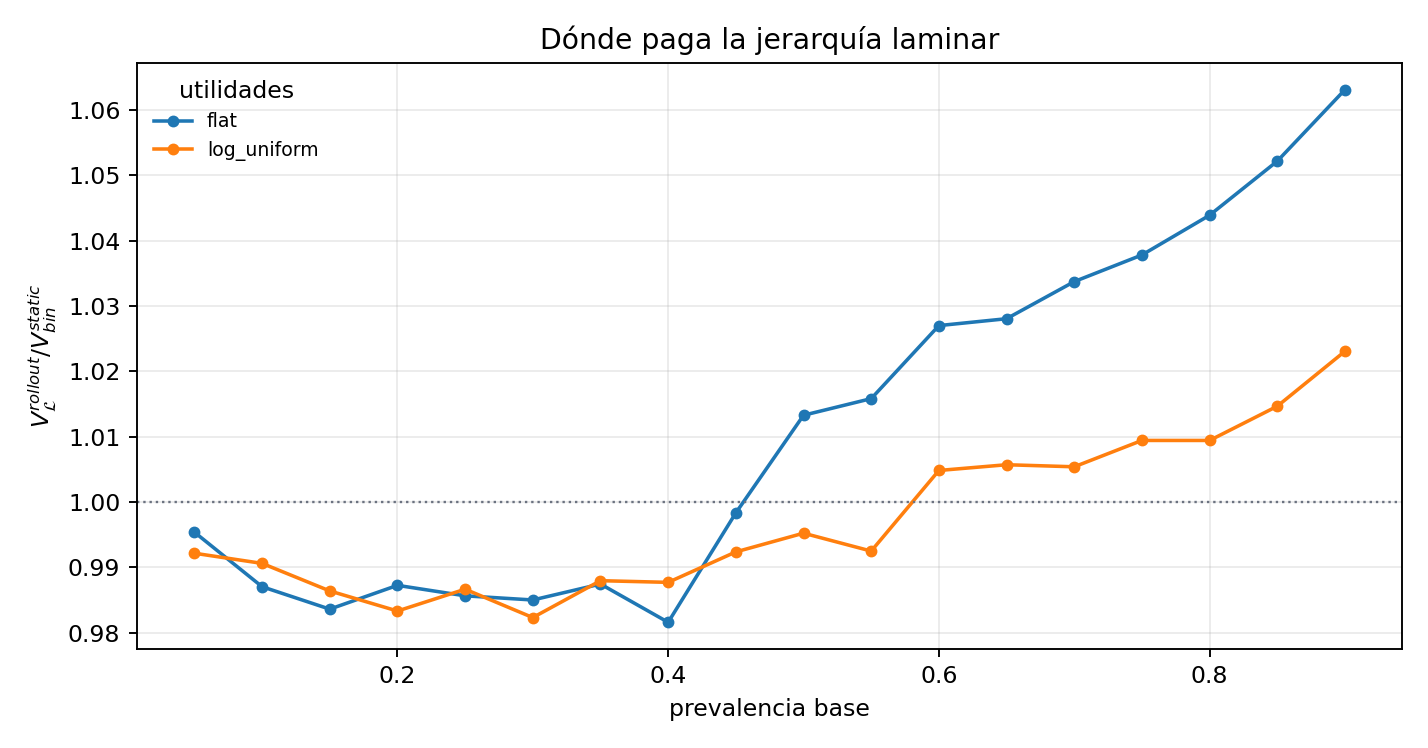

In [16]:
showcase = pd.read_csv(DATA / 'showcase_regions.csv')
display(showcase[[
    'region','instances','share_greedy_beats_static',
    'share_rollout_beats_static','best_gain_rollout_static',
    'best_p','best_n','best_B','best_G','best_utility_mode',
]].round(4))
display(Image(filename=str(FIGURES / 'showcase_regions.png')))

**EVIDENCIA que confirma la intuición de la sesión.** La prevalencia
es la variable que decide: en prevalencia alta ($p\ge0.6$) el rollout laminar
gana al mejor estático binario en **98.2%** de las instancias, contra
**50.9%** en prevalencia baja ($p\le0.2$). Las tasas homogéneas ayudan
(87.5% contra 61.8% con tasas dispersas), también como se anticipó.

**Matiz que la sesión no anticipó:** la mejor instancia del atlas tiene
utilidades **planas** ($p=0.90$, $n=4$, $B=3$, $G=2$), con ganancia de
$1.243$ ($0.373$ contra $0.300$). Que el primer paso coincida con el estático
no impide la ganancia: ésta se produce en los pasos $2\ldots B$, cuando el
conteo del primer pool ya partió la población en átomos. La conclusión
correcta no es "las utilidades planas no sirven" sino "la ganancia laminar es
un fenómeno de horizonte, no del primer paso".

## 12. Balance y dirección del notebook 23

### Resultado sólido

- Inferencia laminar por átomos y predicción exacta de conteos sin multiplicar
  marginales dependientes.
- Policy improvement del rollout con esperanzas exactas.
- $V^{\mathcal L}$ exacto para todo el atlas pequeño mediante cliques
  maximales.
- MILP exacto sobre la distribución empírica; objetivo fraccional no implica
  gap del solver.
- Las tablas de los átomos hijos se derivan de la caché del padre con cero
  convoluciones y error exactamente nulo.

### Resultado empírico que cambia la dirección

- La mejor razón laminar del atlas no es el problema; el mínimo fue 0.928 y la
  búsqueda local llegó a 0.9069.
- La jerarquía práctica/greedy sí puede perder mucho: hasta 0.747 frente al
  óptimo laminar y 0.749 frente al estático.
- La dominancia greedy-laminar/estático no es global en la malla, pero sí es
  casi total donde la sesión predijo: 98.2% en prevalencia alta contra 50.9%
  en prevalencia baja.
- El caso homogéneo $B\le2$ dio igualdad en todos los puntos y es el blanco
  teórico más limpio.
- El ahorro de la caché de subconjuntos es estructural (96× en convoluciones)
  pero no operativo (~1.2× en tiempo): materializar $2^G$ filas domina, así
  que el diseño correcto consulta filas por demanda.

### Decisión sugerida

El eje del notebook 23 debe ser **la frontera de régimen**: demostrar o
refutar $V^{\mathcal L}=V^*$ para $B=2$ homogéneo y explicar por qué la
igualdad se rompe en $B=3$. El atlas y la instancia adversaria 0.9069 quedan
como mapa y contra-presión; el pipeline grande queda como prueba de
arquitectura, no como evidencia de dominancia.

### Reproducción

```bash
python -m augmented.experiments_laminar_week all --workers 4
python -m augmented.experiments_laminar_week tables
python -m augmented.experiments_laminar_week showcase
PYTHONPATH=. python augmented/tests_laminar_milp.py    # 11/11
PYTHONPATH=. python augmented/tests_laminar_tables.py  #  7/7
python augmented/notebooks/build_milp_laminar_notebook.py
jupyter nbconvert --to notebook --execute --inplace \
  augmented/notebooks/22_milp_laminar.ipynb
```

Las suites requieren Python ≥3.10 (`int.bit_count`).

Los artefactos por instancia están en `augmented/data/laminar_week/`; las
figuras externas están en `augmented/notebooks/figures/22_laminar_week/`.